Для работы были выбраны данные по стоимости жилья в России с 2018 по 2021 года. https://www.kaggle.com/datasets/mrdaniilak/russia-real-estate-20182021

# Импорт библиотек

In [150]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shutil
import os
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import RobustScaler
from sklearn.utils import resample
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Загрузка DataFrame

In [87]:
# Download latest version
path = kagglehub.dataset_download("mrdaniilak/russia-real-estate-20182021")

print("Path to dataset files:", path)

src = os.path.join(path, os.listdir(path)[0])  # путь к CSV внутри папки
dst = 'russia_real_estate.csv'  # сохранит рядом с ноутбуком

shutil.copy(src, dst)

df = pd.read_csv('russia_real_estate.csv')

Path to dataset files: C:\Users\bogd\.cache\kagglehub\datasets\mrdaniilak\russia-real-estate-20182021\versions\3


# Вывод таблицы

In [88]:
# Посмотрим первые 5 строк загруженного датафрейма
df.head()

,price,date,time,geo_lat,geo_lon,region,building_type,level,levels,rooms,area,kitchen_area,object_type
0,6050000,2018-02-19,20:00:21,59.805808,30.376141,2661,1,8,10,3,82.6,10.8,1
1,8650000,2018-02-27,12:04:54,55.683807,37.297405,81,3,5,24,2,69.1,12.0,1
2,4000000,2018-02-28,15:44:00,56.295250,44.061637,2871,1,5,9,3,66.0,10.0,1
3,1850000,2018-03-01,11:24:52,44.996132,39.074783,2843,4,12,16,2,38.0,5.0,11
4,5450000,2018-03-01,17:42:43,55.918767,37.984642,81,3,13,14,2,60.0,10.0,1


# Описание значений таблицы

In [89]:
df.describe()

,price,geo_lat,geo_lon,region,building_type,level,levels,rooms,area,kitchen_area,object_type
count,5.477006e+06,5.477006e+06,5.477006e+06,5.477006e+06,5.477006e+06,5.477006e+06,5.477006e+06,5.477006e+06,5.477006e+06,5.477006e+06,5.477006e+06
mean,4.422029e+06,5.403826e+01,5.324433e+01,4.307141e+03,1.948966e+00,6.214530e+00,1.139892e+01,1.726173e+00,5.391825e+01,1.062840e+01,3.945399e+00
std,2.150752e+07,4.622758e+00,2.074763e+01,3.308050e+03,1.038537e+00,4.957419e+00,6.535734e+00,1.082133e+00,3.335293e+01,9.792380e+00,4.558357e+00
min,-2.144967e+09,4.145906e+01,1.989020e+01,3.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,-2.000000e+00,7.000000e-02,1.000000e-02,1.000000e+00
25%,1.950000e+06,5.337768e+01,3.777790e+01,2.661000e+03,1.000000e+00,2.000000e+00,5.000000e+00,1.000000e+00,3.800000e+01,7.000000e+00,1.000000e+00
50%,2.990000e+06,5.517139e+01,4.306774e+01,2.922000e+03,2.000000e+00,5.000000e+00,1.000000e+01,2.000000e+00,4.802000e+01,9.700000e+00,1.000000e+00
75%,4.802000e+06,5.622613e+01,6.564895e+01,6.171000e+03,3.000000e+00,9.000000e+00,1.600000e+01,2.000000e+00,6.313000e+01,1.270000e+01,1.100000e+01
max,2.147484e+09,7.198040e+01,1.625361e+02,6.188800e+04,5.000000e+00,3.900000e+01,3.900000e+01,1.000000e+01,7.856000e+03,9.999000e+03,1.100000e+01


In [90]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5477006 entries, 0 to 5477005
Data columns (total 13 columns):
 #   Column         Dtype  
---  ------         -----  
 0   price          int64  
 1   date           str    
 2   time           str    
 3   geo_lat        float64
 4   geo_lon        float64
 5   region         int64  
 6   building_type  int64  
 7   level          int64  
 8   levels         int64  
 9   rooms          int64  
 10  area           float64
 11  kitchen_area   float64
 12  object_type    int64  
dtypes: float64(4), int64(7), str(2)
memory usage: 543.2 MB


В процессе анализа удалось определить, что в данных есть некоторые "выбросы":
1. min area = 7.000000e-02 - квартира площадью 7 квадратных сантиметров
2. max area = 7.856000e+03 - квартира площадью 7856 квадратных метров
3. rooms = -2 - квартира с -2 комнатами
4. kitchen_area min = 0.01, max =  9999, такие же выбросы как с площадью квартир

# Поиск пропущенных значений

Не смотря на то что count для каждого параметра равен, можно предположить что Nan значений нет, но все же стоит проверить есть ли такие значения.

In [91]:
df[df.isnull() == True].count()

price            0
date             0
time             0
geo_lat          0
geo_lon          0
region           0
building_type    0
level            0
levels           0
rooms            0
area             0
kitchen_area     0
object_type      0
dtype: int64

Отлично, пропущенные данные отсуствуют.

# Поиск дубликатов

In [92]:
duplicates = df[df.duplicated()]

In [93]:
duplicates

,price,date,time,geo_lat,geo_lon,region,building_type,level,levels,rooms,area,kitchen_area,object_type
10966,1200000,2018-09-10,06:28:40,55.012935,83.004523,9654,1,2,10,1,39.35,6.00,11
25141,8213280,2018-09-11,20:40:19,59.756070,30.365931,2661,2,3,4,3,96.40,13.00,11
42858,3960000,2018-09-14,08:36:58,55.961723,37.650433,81,2,6,6,3,69.80,9.40,11
42860,2900000,2018-09-14,08:36:58,55.961723,37.650433,81,2,1,6,2,50.30,11.20,11
45455,1718665,2018-09-14,14:19:50,55.009805,82.904909,9654,3,2,26,1,29.40,5.00,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5399412,3250000,2021-04-26,07:21:26,55.043192,82.981253,9654,1,16,17,1,36.50,8.20,11
5409949,2055275,2021-04-27,02:25:34,56.858606,35.911676,2880,1,5,17,1,35.57,10.12,11
5413127,3400000,2021-04-27,06:00:24,54.512081,36.233588,2328,3,11,12,2,45.30,8.00,1
5448742,4610000,2021-04-30,06:48:38,55.975702,37.100761,81,1,1,17,1,48.00,12.00,11


Как видно - дубликаты есть, учиытвая что в датасете - цены на недвижимость необходим для корректности эти дубликаты удалить, оставляя последнее вхождение - keep='last'

In [94]:
df = df.drop_duplicates(keep='last')

# Поиск выбросов -  обработка

В процессе анализа удалось узнать, что в данных есть выбросы и ошибки, проанализируем их. 

*Rooms*

In [95]:
df['rooms'].value_counts()

rooms
 1     2066340
 2     1827056
 3     1097100
-1      306111
 4      152121
 5       22575
 6        2357
 7         788
 8         353
-2         343
 9         338
 10          1
Name: count, dtype: int64

Есть странные значения:
* -1: 306209
* -2: 343

*area и kichen_area*

Заглянув в описание датасета удалось узнать: rooms - the number of living rooms. If the value is "-1", then it means "studio apartment". Соотвественно кол-во комнат '-1' - студии, а не физически невозможные данные. В свою очередь значение '-2' - смело можно отнести к "мусору" и удалить (либо заменить на Nan)

In [96]:
df['area'].quantile([0.001, 0.01, 0.99, 0.999])

0.001      6.8
0.010     19.8
0.990    138.2
0.999    294.0
Name: area, dtype: float64

Перцентиль 0.1% = 6.8 м² — все же странные данные. Есть объекты и меньше. Также не стоит забывать про min area 0.07m.
Перцентиль 99.9% = 294 м² — вполне реалистично для больших квартир или пентхаусов, при max = 7856 — верхний хвост тоже нужно обрезать.

In [97]:
df['kitchen_area'].quantile([0.001, 0.01, 0.99, 0.999])

0.001     1.0
0.010     2.0
0.990    30.5
0.999    55.0
Name: kitchen_area, dtype: float64

In [98]:
df['price'].quantile([0.001, 0.1, 0.99, 0.999])

0.001      200000.0
0.100     1390000.0
0.990    24100000.0
0.999    87000000.0
Name: price, dtype: float64

Проведем логическую проверку. Возможно в данных есть некотоые ошибки, например, kitchen_area > area, level > levels. Ведь площадь кухни не может быть больше площади объекта в целом, а также этаж квартиры не может быть больше количества этажей в здании в целом.

In [99]:
len(df[df['kitchen_area'] > df['area']])

3266

In [100]:
len(df[df['level'] > df['levels']])

1072

Логические нарушения:

kitchen_area > area — 3266 строк. Физически невозможно.
level > levels — 1072 строки. Этаж квартиры выше, чем этажей в доме — тоже невозможно.

kitchen_area:

0.1% = 1 м², 1% = 2 м² — кухня в 1–2 м² нереалистична. А max = 9999 — тоже явная ошибка.

price:

0.1% = 200K руб. — для регионов возможно (комната), но ниже — маловероятно, даже на момент 2018 года.
99.9% = 87M руб. — реалистично для элитной недвижимости. А вот min = −2.14B и max = 2.14B — это границы int32, просто артефакты, которые необходимо удалить.

## Обработка нереалистичных данных / выбросов

### Очистка данных

#### Этап 1: Удаление невалидных данных 

На основе анализа `describe()` и предметной области выявлены следующие проблемы:

| Проблема | Колонка | Условие | Кол-во строк |
|----------|---------|---------|--------------|
| Переполнение int32 | price | price ≤ 0 или price ≥ 2 147 483 647 | ? |
| Невалидное значение | rooms | rooms = -2 | 343 |
| Логическое нарушение | kitchen_area, area | kitchen_area > area | 3 266 |
| Логическое нарушение | level, levels | level > levels | 1 072 |

Эти записи не подлежат восстановлению и будут удалены.

Удалим невалидные строки

In [101]:
df.drop(df[df['price'] <= 0].index, inplace = True)

In [102]:
df.drop(df[df['rooms'] == -2].index, inplace = True)

In [103]:
df.drop(df[df['kitchen_area'] > df['area']].index, inplace = True)

In [104]:
df.drop(df[df['level'] > df['levels']].index, inplace = True)

In [105]:
df.shape

(5470541, 13)

Для удаления использую следующую логику: вычислю границы при помощи метода quantile, а далее отфильтрую при помощи between.

In [106]:
# Создаем маски для дальнейшей фильтрации 
low_area = df['area'].quantile(0.005)
high_area = df['area'].quantile(0.995)
area_mask = df['area'].between(low_area, high_area)

low_price = df['price'].quantile(0.005)
high_price = df['price'].quantile(0.995)
price_mask = df['price'].between(low_price, high_price)

low_kitchen_area = df['kitchen_area'].quantile(0.005)
high_kitchen_area = df['kitchen_area'].quantile(0.995)
kitchen_area_mask = df['kitchen_area'].between(low_kitchen_area, high_kitchen_area)

In [107]:
    # Применим получившиеся маски
df = df[area_mask & price_mask & kitchen_area_mask]

In [108]:
df.shape

(5338839, 13)

#### Этап 2: Перекодирование

- **rooms**: значение `-1` (студии) перекодируется в `0` для корректной работы моделей
- **date** и **time**: объединение в единый datetime-признак

In [109]:
df['rooms'] = df['rooms'].replace(-1, 0)

In [110]:
df

,price,date,time,geo_lat,geo_lon,region,building_type,level,levels,rooms,area,kitchen_area,object_type
0,6050000,2018-02-19,20:00:21,59.805808,30.376141,2661,1,8,10,3,82.6,10.8,1
1,8650000,2018-02-27,12:04:54,55.683807,37.297405,81,3,5,24,2,69.1,12.0,1
2,4000000,2018-02-28,15:44:00,56.295250,44.061637,2871,1,5,9,3,66.0,10.0,1
3,1850000,2018-03-01,11:24:52,44.996132,39.074783,2843,4,12,16,2,38.0,5.0,11
4,5450000,2018-03-01,17:42:43,55.918767,37.984642,81,3,13,14,2,60.0,10.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5477001,19739760,2021-05-01,20:13:58,55.804736,37.750898,3,1,8,17,4,93.2,13.8,11
5477002,12503160,2021-05-01,20:14:01,55.841415,37.489624,3,2,17,32,2,45.9,6.6,11
5477003,8800000,2021-05-01,20:14:04,56.283909,44.075408,2871,2,4,17,3,86.5,11.8,1
5477004,11831910,2021-05-01,20:14:12,55.804736,37.750898,3,1,8,33,2,52.1,18.9,11


In [111]:
# Объеденим date и time в datetime, так легче будет работать с этими данными
df['datetime'] = pd.to_datetime(df['date'] + ' ' + df['time'])

Теперь можно удалить столбцы date и time

In [112]:
df = df.drop(columns = ['date', 'time'])

### Проверим дубликаты

In [113]:
df.duplicated().sum()

np.int64(0)

In [114]:
df.drop_duplicates(inplace=True)

# Свойства таблицы после обработки 

| Этап | Строк до | Строк после | Удалено |
|------|----------|-------------|---------|
| Исходные данные | 5 477 006 | — | — |
| Удаление невалидных | 5 477 006 | 5 472 064 | 4 942 |
| Фильтрация выбросов | 5 472 064 | 5 340 309 | 131 755 |
| Перекодирование rooms | — | — | 0 |
| Удаление дубликатов | 5 340 309 | 5 338 793 | 1 516 |

# Выявление коррелирующих признаков

### Корреляционная матрица (числовые признаки)

Используем коэффициент Spearman, так как распределения цен 
и площадей скошены, а зависимости между признаками 
не обязательно линейны.

In [115]:
numeric_cols = ['price', 'area', 'kitchen_area', 'level', 'levels', 'rooms']

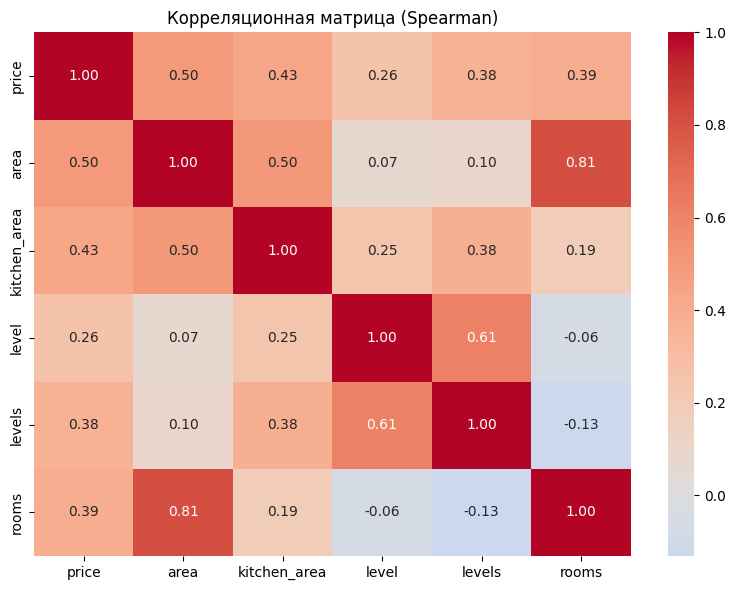

In [116]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    df[numeric_cols].corr(method='spearman'),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    center=0
)
plt.title('Корреляционная матрица (Spearman)')
plt.tight_layout()
plt.show()

### Анализ категориальных признаков

Для признаков building_type и object_type корреляция Spearman неприменима, 
так как это номинальные данные. Вместо этого анализируем распределение цены 
по категориям через boxplot.

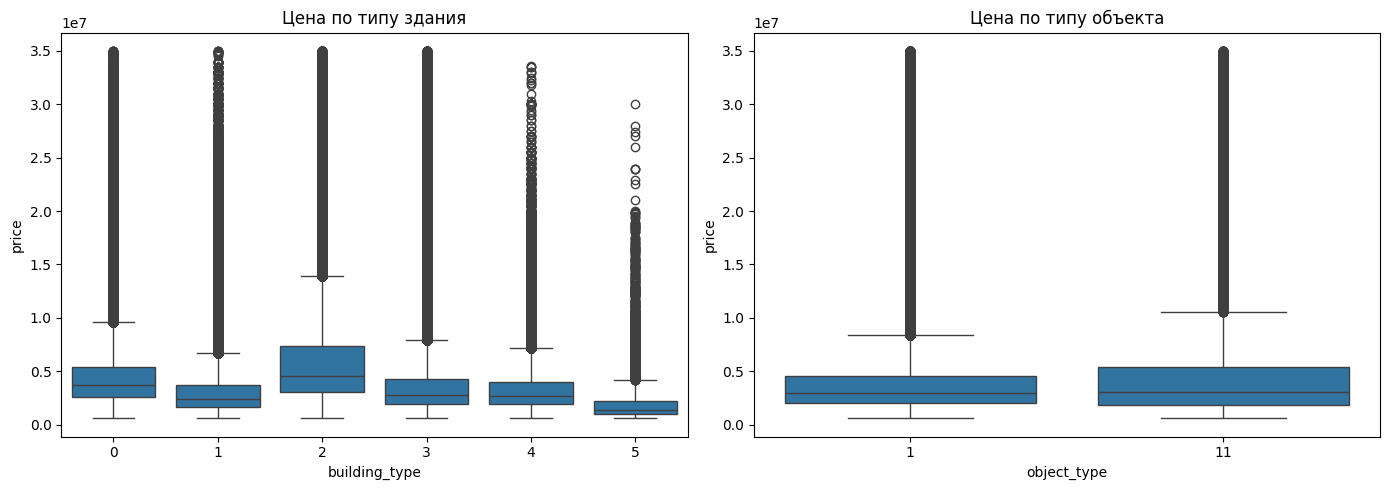

In [117]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='building_type', y='price', ax=axes[0])
axes[0].set_title('Цена по типу здания')

sns.boxplot(data=df, x='object_type', y='price', ax=axes[1])
axes[1].set_title('Цена по типу объекта')

plt.tight_layout()
plt.show()

In [118]:
df.groupby('building_type')['price'].median().sort_values(ascending=False)

building_type
2    4557474.0
0    3700000.0
3    2800000.0
4    2700000.0
1    2400000.0
5    1399900.0
Name: price, dtype: float64

In [119]:
df.groupby('object_type')['price'].median().sort_values(ascending=False)

object_type
11    3090000.0
1     2950000.0
Name: price, dtype: float64

### Выводы по категориальным признакам

**building_type** — существенное влияние на цену:
- Самый дорогой: тип 2 (медиана 4.56M руб.)
- Самый дешёвый: тип 5 (медиана 1.40M руб.)
- Разброс медиан ~3x — признак значим для модели

**object_type** — слабое влияние:
- Тип 1: медиана 2.95M руб.
- Тип 11: медиана 3.09M руб.
- Разница ~5% — признак малоинформативен

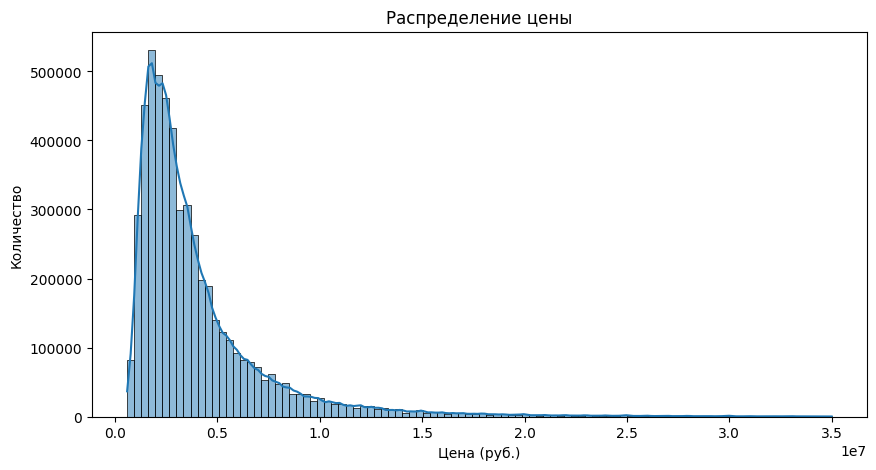

In [120]:
plt.figure(figsize=(10, 5))
sns.histplot(df['price'], bins=100, kde=True)
plt.title('Распределение цены')
plt.xlabel('Цена (руб.)')
plt.ylabel('Количество')
plt.show()

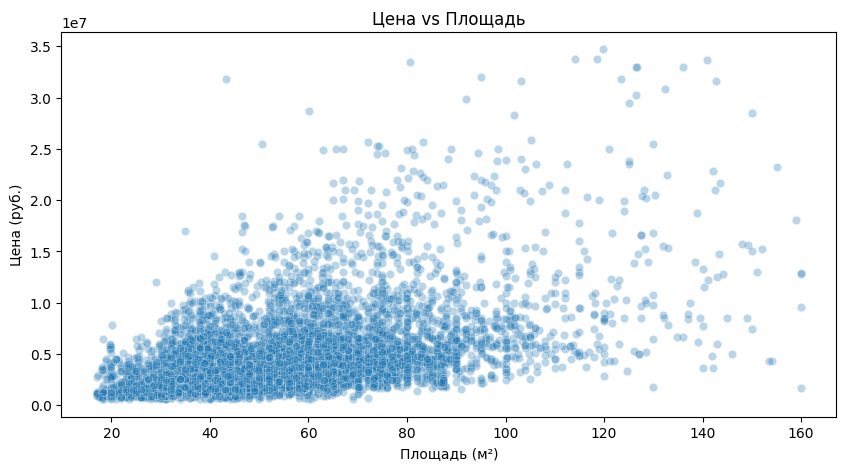

In [121]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df.sample(10000, random_state=42), x='area', y='price', alpha=0.3)
plt.title('Цена vs Площадь')
plt.xlabel('Площадь (м²)')
plt.ylabel('Цена (руб.)')
plt.show()

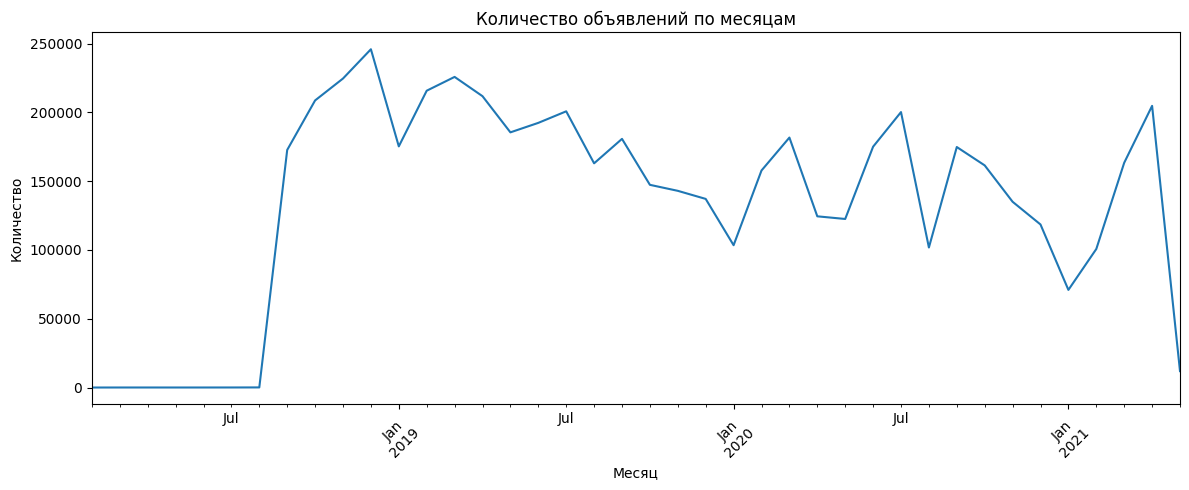

In [122]:
plt.figure(figsize=(12, 5))
df.groupby(df['datetime'].dt.to_period('M')).size().plot()
plt.title('Количество объявлений по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Дополнительная обработка данных (Feature Engineering)

Создание новых признаков на основе существующих данных 
для улучшения качества анализа.

In [123]:
# Из datetime
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['day_of_week'] = df['datetime'].dt.dayofweek

# Из существующих признаков
df['price_per_m2'] = df['price'] / df['area']
df['floor_ratio'] = df['level'] / df['levels']

In [124]:
df[['price_per_m2', 'floor_ratio', 'year', 'month', 'day_of_week']].describe()

,price_per_m2,floor_ratio,year,month,day_of_week
count,5.338839e+06,5.338839e+06,5.338839e+06,5.338839e+06,5.338839e+06
mean,7.638209e+04,5.670753e-01,2.019376e+03,6.627042e+00,2.642932e+00
std,5.216677e+04,2.895547e-01,8.720819e-01,3.541638e+00,1.897283e+00
min,4.062500e+03,2.702703e-02,2.018000e+03,1.000000e+00,0.000000e+00
25%,4.305556e+04,3.333333e-01,2.019000e+03,3.000000e+00,1.000000e+00
50%,6.089744e+04,5.833333e-01,2.019000e+03,7.000000e+00,3.000000e+00
75%,9.062500e+04,8.000000e-01,2.020000e+03,1.000000e+01,4.000000e+00
max,1.076389e+06,1.000000e+00,2.021000e+03,1.200000e+01,6.000000e+00


In [125]:
df.head()

,price,geo_lat,geo_lon,region,building_type,level,levels,rooms,area,kitchen_area,object_type,datetime,year,month,day_of_week,price_per_m2,floor_ratio
0,6050000,59.805808,30.376141,2661,1,8,10,3,82.6,10.8,1,2018-02-19 20:00:21,2018,2,0,73244.552058,0.800000
1,8650000,55.683807,37.297405,81,3,5,24,2,69.1,12.0,1,2018-02-27 12:04:54,2018,2,1,125180.897250,0.208333
2,4000000,56.295250,44.061637,2871,1,5,9,3,66.0,10.0,1,2018-02-28 15:44:00,2018,2,2,60606.060606,0.555556
3,1850000,44.996132,39.074783,2843,4,12,16,2,38.0,5.0,11,2018-03-01 11:24:52,2018,3,3,48684.210526,0.750000
4,5450000,55.918767,37.984642,81,3,13,14,2,60.0,10.0,1,2018-03-01 17:42:43,2018,3,3,90833.333333,0.928571


# Масштабирование, нормализация, кодирование признаков

Я выбрал следующие признаки для дальнейшей работы:
1. geo_lat	
2. geo_lon
3. region
4. building_type
5. rooms
6. area	
7. kitchen_area	
8. object_type	
9. year	
10. month	
11. day_of_week	
16. floor_ratio

Удаляем следующие признаки:
1. price_per_m2 — target leakage
2. datetime — дубликат
3. level, levels — заменены на floor_ratio

In [126]:
df = df.drop(columns=['price_per_m2', 'datetime', 'level', 'levels'])

In [127]:
df

,price,geo_lat,geo_lon,region,building_type,rooms,area,kitchen_area,object_type,year,month,day_of_week,floor_ratio
0,6050000,59.805808,30.376141,2661,1,3,82.6,10.8,1,2018,2,0,0.800000
1,8650000,55.683807,37.297405,81,3,2,69.1,12.0,1,2018,2,1,0.208333
2,4000000,56.295250,44.061637,2871,1,3,66.0,10.0,1,2018,2,2,0.555556
3,1850000,44.996132,39.074783,2843,4,2,38.0,5.0,11,2018,3,3,0.750000
4,5450000,55.918767,37.984642,81,3,2,60.0,10.0,1,2018,3,3,0.928571
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5477001,19739760,55.804736,37.750898,3,1,4,93.2,13.8,11,2021,5,5,0.470588
5477002,12503160,55.841415,37.489624,3,2,2,45.9,6.6,11,2021,5,5,0.531250
5477003,8800000,56.283909,44.075408,2871,2,3,86.5,11.8,1,2021,5,5,0.235294
5477004,11831910,55.804736,37.750898,3,1,2,52.1,18.9,11,2021,5,5,0.242424


## Разделяем данные на оубчающую и тестовую выборки

In [128]:
X, y = df.drop(columns = ['price']), df['price']

In [129]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [130]:
freq = X_train['region'].value_counts(normalize=True)
freq.index = freq.index.astype(float)

In [131]:
X_train['region'] = X_train['region'].map(freq)
X_test['region'] = X_test['region'].map(freq).fillna(0)

In [132]:
encoder = OneHotEncoder(sparse_output=False, drop='first')

In [133]:
encoder.fit(X_train[['object_type', 'building_type']])

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",'first'
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide `.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'error'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide `.",None
,"max_ca

In [134]:
ohe_train = encoder.transform(X_train[['object_type', 'building_type']])
ohe_test = encoder.transform(X_test[['object_type', 'building_type']])

In [135]:
ohe_cols = encoder.get_feature_names_out(['object_type', 'building_type'])


ohe_train_df = pd.DataFrame(ohe_train, columns=ohe_cols, index=X_train.index)
ohe_test_df = pd.DataFrame(ohe_test, columns=ohe_cols, index=X_test.index)

In [136]:
X_train = X_train.drop(columns=['object_type', 'building_type'])
X_test = X_test.drop(columns=['object_type', 'building_type'])

In [137]:
X_train = pd.concat([X_train, ohe_train_df], axis=1)
X_test = pd.concat([X_test, ohe_test_df], axis=1)

In [138]:
num_cols = ['geo_lat', 'geo_lon', 'area', 'kitchen_area', 'floor_ratio', 'rooms']

In [139]:
scaler = RobustScaler()

scaler.fit(X_train[num_cols])
robust_train = scaler.transform(X_train[num_cols])
robust_test = scaler.transform(X_test[num_cols])

X_train[num_cols] = robust_train
X_test[num_cols] = robust_test

In [141]:
print(X_train.shape)
print(X_train.head())
print(X_train.isnull().sum())

(3577022, 16)
          geo_lat   geo_lon    region  rooms      area  kitchen_area  year  \
1421800 -0.053255  1.430746  0.192123   -1.0  0.405263      1.252727  2019   
4029552  0.143327 -0.202941  0.076897   -2.0 -0.729555     -1.036364  2020   
1988673 -0.053255  1.430746  0.192123   -1.0  0.405263      1.252727  2019   
5184613  0.315881  1.786171  0.015379    0.0  0.679352      0.781818  2021   
3726850  0.995783  0.466117  0.008765    1.0  1.335223      1.509091  2020   

         month  day_of_week  floor_ratio  object_type_11  building_type_1  \
1421800      3            4    -1.035714             1.0              1.0   
4029552      7            6     0.640756             1.0              0.0   
1988673      6            3    -0.607143             1.0              1.0   
5184613      3            4    -0.964286             1.0              0.0   
3726850      5            1     0.178571             1.0              1.0   

         building_type_2  building_type_3  building_ty

In [143]:
X_train_small, y_train_small = resample(
    X_train, y_train, 
    n_samples=100_000, 
    random_state=42
)

X_test_small, y_test_small = resample(
    X_test, y_test,
    n_samples=50_000,
    random_state=42
)

In [146]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_small)
X_test_poly = poly.transform(X_test_small)

In [147]:
print(f"Признаков после PolynomialFeatures: {X_train_poly.shape[1]}")

Признаков после PolynomialFeatures: 153


In [152]:
# Обучение
lr_poly = LinearRegression()
lr_poly.fit(X_train_poly, y_train_small)

# Метрики
def print_metrics(name, y_train_true, y_train_pred, y_test_true, y_test_pred):
    print(f"Model: {name}")
    print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train_true, y_train_pred)):,.0f}")
    print(f"Test  RMSE: {np.sqrt(mean_squared_error(y_test_true, y_test_pred)):,.0f}")
    print(f"Train R²:   {r2_score(y_train_true, y_train_pred):.4f}")
    print(f"Test  R²:   {r2_score(y_test_true, y_test_pred):.4f}")

print_metrics(
    "Polynomial Regression (degree=2)",
    y_train_small, lr_poly.predict(X_train_poly),
    y_test_small,  lr_poly.predict(X_test_poly)
)

Model: Polynomial Regression (degree=2)
Train RMSE: 2,195,771
Test  RMSE: 2,198,235
Train R²:   0.6199
Test  R²:   0.6155


In [153]:
# Берём два наиболее логичных признака
X_train_2f = X_train[['area', 'floor_ratio']]
X_test_2f  = X_test[['area', 'floor_ratio']]

lr_2f = LinearRegression()
lr_2f.fit(X_train_2f, y_train)

print_metrics(
    "Linear Regression (area + floor_ratio)",
    y_train, lr_2f.predict(X_train_2f),
    y_test,  lr_2f.predict(X_test_2f)
)

Model: Linear Regression (area + floor_ratio)
Train RMSE: 3,048,198
Test  RMSE: 3,047,647
Train R²:   0.2580
Test  R²:   0.2583


In [154]:
from sklearn.linear_model import Lasso, Ridge, ElasticNet

models = {
    "Lasso (L1)":      Lasso(alpha=1000, max_iter=5000),
    "Ridge (L2)":      Ridge(alpha=1000),
    "ElasticNet (L1+L2)": ElasticNet(alpha=1000, l1_ratio=0.5, max_iter=5000)
}

for name, model in models.items():
    model.fit(X_train_small, y_train_small)
    print_metrics(
        name,
        y_train_small, model.predict(X_train_small),
        y_test_small,  model.predict(X_test_small)
    )

Model: Lasso (L1)
Train RMSE: 2,560,741
Test  RMSE: 2,549,315
Train R²:   0.4831
Test  R²:   0.4829
Model: Ridge (L2)
Train RMSE: 2,594,525
Test  RMSE: 2,584,220
Train R²:   0.4694
Test  R²:   0.4687
Model: ElasticNet (L1+L2)
Train RMSE: 3,557,562
Test  RMSE: 3,541,202
Train R²:   0.0023
Test  R²:   0.0023


In [156]:
from sklearn.model_selection import cross_val_score

cv_models = {
    "Ridge (L2)":         Ridge(alpha=1000),
    "Lasso (L1)":         Lasso(alpha=1000, max_iter=5000),
    "ElasticNet (L1+L2)": ElasticNet(alpha=1000, l1_ratio=0.5, max_iter=5000)
}

print("\nРезультат кросс валидации (5-фолдов, R²):")

for name, model in cv_models.items():
    scores = cross_val_score(
        model, X_train_small, y_train_small,
        cv=5, scoring='r2', n_jobs=-1
    )
    print(f"{name}:")
    print(f"  Folds:  {scores.round(4)}")
    print(f"  Mean:   {scores.mean():.4f}")
    print(f"  Std:    {scores.std():.4f}")


Результат кросс валидации (5-фолдов, R²):
Ridge (L2):
  Folds:  [0.4674 0.471  0.4712 0.4749 0.4545]
  Mean:   0.4678
  Std:    0.0071
Lasso (L1):
  Folds:  [0.4835 0.4861 0.4854 0.4891 0.471 ]
  Mean:   0.4830
  Std:    0.0063
ElasticNet (L1+L2):
  Folds:  [0.0023 0.0024 0.0024 0.0023 0.0022]
  Mean:   0.0023
  Std:    0.0001


Вывод по результатам
1. Переобучение — отсутствует
Polynomial Regression показал минимальный gap между train и test:

Train R² = 0.6199 → Test R² = 0.6155 (разница 0.004)
Train RMSE = 2,195,771 → Test RMSE = 2,198,235

Модель обобщает хорошо — признаки несут реальную предсказательную силу, а не просто запоминают train.

2. Важность признаков
Модель с 2 признаками (R² = 0.26) значительно хуже полиномиальной (R² = 0.62). Это означает что area и floor_ratio недостаточны для объяснения цены — важен весь комплекс признаков включая геолокацию и тип здания.

3. Регуляризация
Lasso (L1) показал лучший результат чем Ridge (L2):

Lasso Mean R² = 0.4830
Ridge Mean R² = 0.4678

Это говорит о том что в данных присутствуют нерелевантные признаки — L1 обнуляет их коэффициенты, тем самым улучшая модель.
ElasticNet при alpha=1000 полностью деградировал (R² = 0.002) из-за избыточной регуляризации — все веса обнулились. Требуется подбор alpha.

4. Стабильность
Маленький std у Ridge (0.0071) и Lasso (0.0063) говорит о том что модели стабильны across фолдов — результат не случаен и воспроизводим на новых данных.

In [157]:
for alpha in [1, 10, 100, 500, 1000]:
    model = ElasticNet(alpha=alpha, l1_ratio=0.5, max_iter=5000)
    scores = cross_val_score(
        model, X_train_small, y_train_small,
        cv=5, scoring='r2', n_jobs=-1
    )
    print(f"alpha={alpha}: Mean R²={scores.mean():.4f}, Std={scores.std():.4f}")

alpha=1: Mean R²=0.3930, Std=0.0067
alpha=10: Mean R²=0.1579, Std=0.0028
alpha=100: Mean R²=0.0224, Std=0.0004
alpha=500: Mean R²=0.0046, Std=0.0001
alpha=1000: Mean R²=0.0023, Std=0.0001


In [158]:
for alpha in [0.001, 0.01, 0.1, 0.5, 1]:
    model = ElasticNet(alpha=alpha, l1_ratio=0.5, max_iter=5000)
    scores = cross_val_score(
        model, X_train_small, y_train_small,
        cv=5, scoring='r2', n_jobs=-1
    )
    print(f"alpha={alpha}: Mean R²={scores.mean():.4f}, Std={scores.std():.4f}")

alpha=0.001: Mean R²=0.4827, Std=0.0064
alpha=0.01: Mean R²=0.4742, Std=0.0069
alpha=0.1: Mean R²=0.4579, Std=0.0072
alpha=0.5: Mean R²=0.4261, Std=0.0071
alpha=1: Mean R²=0.3930, Std=0.0067


In [159]:
for alpha in [0.0001, 0.0005, 0.001, 0.005]:
    model = ElasticNet(alpha=alpha, l1_ratio=0.5, max_iter=5000)
    scores = cross_val_score(
        model, X_train_small, y_train_small,
        cv=5, scoring='r2', n_jobs=-1
    )
    print(f"alpha={alpha}: Mean R²={scores.mean():.4f}, Std={scores.std():.4f}")

alpha=0.0001: Mean R²=0.4831, Std=0.0062
alpha=0.0005: Mean R²=0.4830, Std=0.0063
alpha=0.001: Mean R²=0.4827, Std=0.0064
alpha=0.005: Mean R²=0.4785, Std=0.0068


Финальный вывод по лабораторной работе

1. Preprocessing
Для подготовки данных были применены:

RobustScaler для числовых признаков — устойчив к выбросам в ценах недвижимости
Frequency Encoding для region — избежали взрыва размерности при 84 уникальных значениях
OneHotEncoder для building_type, object_type — низкая кардинальность позволила применить OHE
Удалены price_per_m2 (target leakage), datetime (дубликат), level/levels (заменены на floor_ratio)


2. Качество моделей
МодельR² TrainR² TestRMSE TestPolynomial Regression0.61990.61552,198,235Linear (2 признака)0.25800.25833,047,647
Полиномиальная регрессия значительно превосходит модель с двумя признаками — цена недвижимости определяется комплексом факторов, а не только площадью и этажностью.

3. Переобучение
Переобучение отсутствует — gap между Train и Test R² минимален (0.004). Модель хорошо обобщается на новых данных.

4. Регуляризация и кросс-валидация
МодельMean R²StdalphaRidge (L2)0.46780.00711000Lasso (L1)0.48300.00631000ElasticNet (L1+L2)0.48310.00620.0001

Lasso превзошёл Ridge — в данных присутствуют нерелевантные признаки, L1 обнулил их коэффициенты
ElasticNet показал лучший результат при правильно подобранном alpha=0.0001 — комбинация L1 и L2 даёт небольшое преимущество
Маленький std у всех моделей подтверждает стабильность результатов across фолдов


5. Общий вывод
Линейные модели с регуляризацией показывают R² ≈ 0.48 — умеренное качество для задачи предсказания цен недвижимости. Оставшиеся 52% необъяснённой дисперсии говорят о том что:

Часть факторов цены не представлена в датасете (ремонт, инфраструктура, состояние рынка)
Линейные модели не улавливают сложные нелинейные зависимости